In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("vendor_invoice.csv")
df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN
...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,NaN
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,NaN
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,NaN
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,NaN


In [3]:
import pandas as pd
purchases_df = pd.read_csv("vendor_invoice.csv")
print(purchases_df.columns.tolist())

['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate', 'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval']


In [4]:
import pandas as pd

# 1. Load the dataset
purchases_df = pd.read_csv("vendor_invoice.csv")

# 2. Convert date strings to actual datetime objects using your column names
purchases_df['PayDate'] = pd.to_datetime(purchases_df['PayDate'])
purchases_df['PODate'] = pd.to_datetime(purchases_df['PODate'])

# 3. Calculate the payment delay in days (replacing receiving delay)
purchases_df['receiving_delay'] = (purchases_df['PayDate'] - purchases_df['PODate']).dt.days

# 4. Group by PONumber and aggregate using your exact columns
invoice_flagging_df = purchases_df.groupby('PONumber').agg(
    total_brands=('VendorName', 'nunique'),       # Swapped Brand for VendorName
    total_item_quantity=('Quantity', 'sum'),
    total_item_dollars=('Dollars', 'sum'),
    avg_receiving_delay=('receiving_delay', 'mean')
).reset_index()

# 5. Display the resulting data frame
invoice_flagging_df.head()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,1,10100,137483.78,47.0
1,8107,1,24,348.72,52.0
2,8108,1,8466,60281.13,52.0
3,8109,1,2246,14298.09,53.0
4,8110,1,8086,56493.23,61.0


In [5]:
import pandas as pd

# 1. Ensure date columns are formatted as datetime objects
purchases_df['PODate'] = pd.to_datetime(purchases_df['PODate'])
purchases_df['InvoiceDate'] = pd.to_datetime(purchases_df['InvoiceDate'])
purchases_df['PayDate'] = pd.to_datetime(purchases_df['PayDate'])

# 2. Replicate SQL calculations using pandas datetime components
purchase_agg_df = purchases_df[[
    'VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate', 'PayDate'
]].copy()

purchase_agg_df['invoice_quantity'] = purchases_df['Quantity']
purchase_agg_df['invoice_dollars'] = purchases_df['Dollars']
purchase_agg_df['Freight'] = purchases_df['Freight']

# Calculate days between PO date and Invoice date
purchase_agg_df['days_po_to_invoice'] = (purchases_df['InvoiceDate'] - purchases_df['PODate']).dt.days

# Calculate days between Invoice date and Payment date
purchase_agg_df['days_to_pay'] = (purchases_df['PayDate'] - purchases_df['InvoiceDate']).dt.days

# 3. Check data frame properties to match video checks
print("Dataframe Shape:", purchase_agg_df.shape)
purchase_agg_df.head()

Dataframe Shape: (5543, 11)


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,14,43
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,16,45
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,16,38
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,23,24
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,14,36


In [6]:
import pandas as pd

# 1. Load your dataset
df = pd.read_csv("vendor_invoice.csv")

# 2. Make sure date columns are converted properly
df['PODate'] = pd.to_datetime(df['PODate'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['PayDate'] = pd.to_datetime(df['PayDate'])

# 3. Calculate baseline metrics
df['days_po_to_invoice'] = (df['InvoiceDate'] - df['PODate']).dt.days
df['days_to_pay'] = (df['PayDate'] - df['InvoiceDate']).dt.days
df['receiving_delay'] = (df['PayDate'] - df['PODate']).dt.days

# 4. Create the aggregated group (Replicating the SQL CTE)
pa = df.groupby('PONumber').agg(
    total_brands=('VendorName', 'nunique'),
    total_item_quantity=('Quantity', 'sum'),
    total_item_dollars=('Dollars', 'sum'),
    avg_receiving_delay=('receiving_delay', 'mean')
).reset_index()

# 5. Extract the main invoice tracking columns
vi = df[[
    'PONumber', 'Quantity', 'Dollars', 'Freight', 
    'days_po_to_invoice', 'days_to_pay'
]].copy()

vi = vi.rename(columns={
    'Quantity': 'invoice_quantity',
    'Dollars': 'invoice_dollars'
})

# 6. Replicate the SQL LEFT JOIN
final_flagging_df = pd.merge(vi, pa, on='PONumber', how='left')

# 7. Display the final combined data frame properties
print("Combined Dataframe Shape:", final_flagging_df.shape)
final_flagging_df.head()

Combined Dataframe Shape: (5543, 10)


,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14,43,1,6,214.26,57.0
1,8137,15,140.55,8.57,16,45,1,15,140.55,61.0
2,8169,5,106.60,4.61,16,38,1,5,106.60,54.0
3,8106,10100,137483.78,2935.20,23,24,1,10100,137483.78,47.0
4,8170,1935,15527.25,429.20,14,36,1,1935,15527.25,50.0


In [7]:
df.isnull().sum()

VendorNumber             0
VendorName               0
InvoiceDate              0
PONumber                 0
PODate                   0
PayDate                  0
Quantity                 0
Dollars                  0
Freight                  0
Approval              5169
days_po_to_invoice       0
days_to_pay              0
receiving_delay          0
dtype: int64

In [8]:
df.dtypes

VendorNumber                   int64
VendorName                    object
InvoiceDate           datetime64[ns]
PONumber                       int64
PODate                datetime64[ns]
PayDate               datetime64[ns]
Quantity                       int64
Dollars                      float64
Freight                      float64
Approval                      object
days_po_to_invoice             int64
days_to_pay                    int64
receiving_delay                int64
dtype: object

In [9]:
def create_invoice_risk_label(row):
    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"])) > 5:
        return 1
        
    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
        
    return 0

# Apply the risk label function to your dataframe
final_flagging_df["flag_invoice"] = final_flagging_df.apply(create_invoice_risk_label, axis=1)

# Check the count of flagged vs unflagged invoices
final_flagging_df["flag_invoice"].value_counts()

flag_invoice
1    5543
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

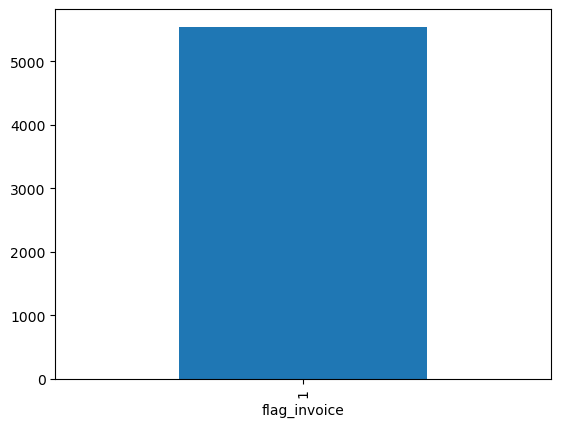

In [10]:
final_flagging_df['flag_invoice'].value_counts().plot(kind = 'bar')

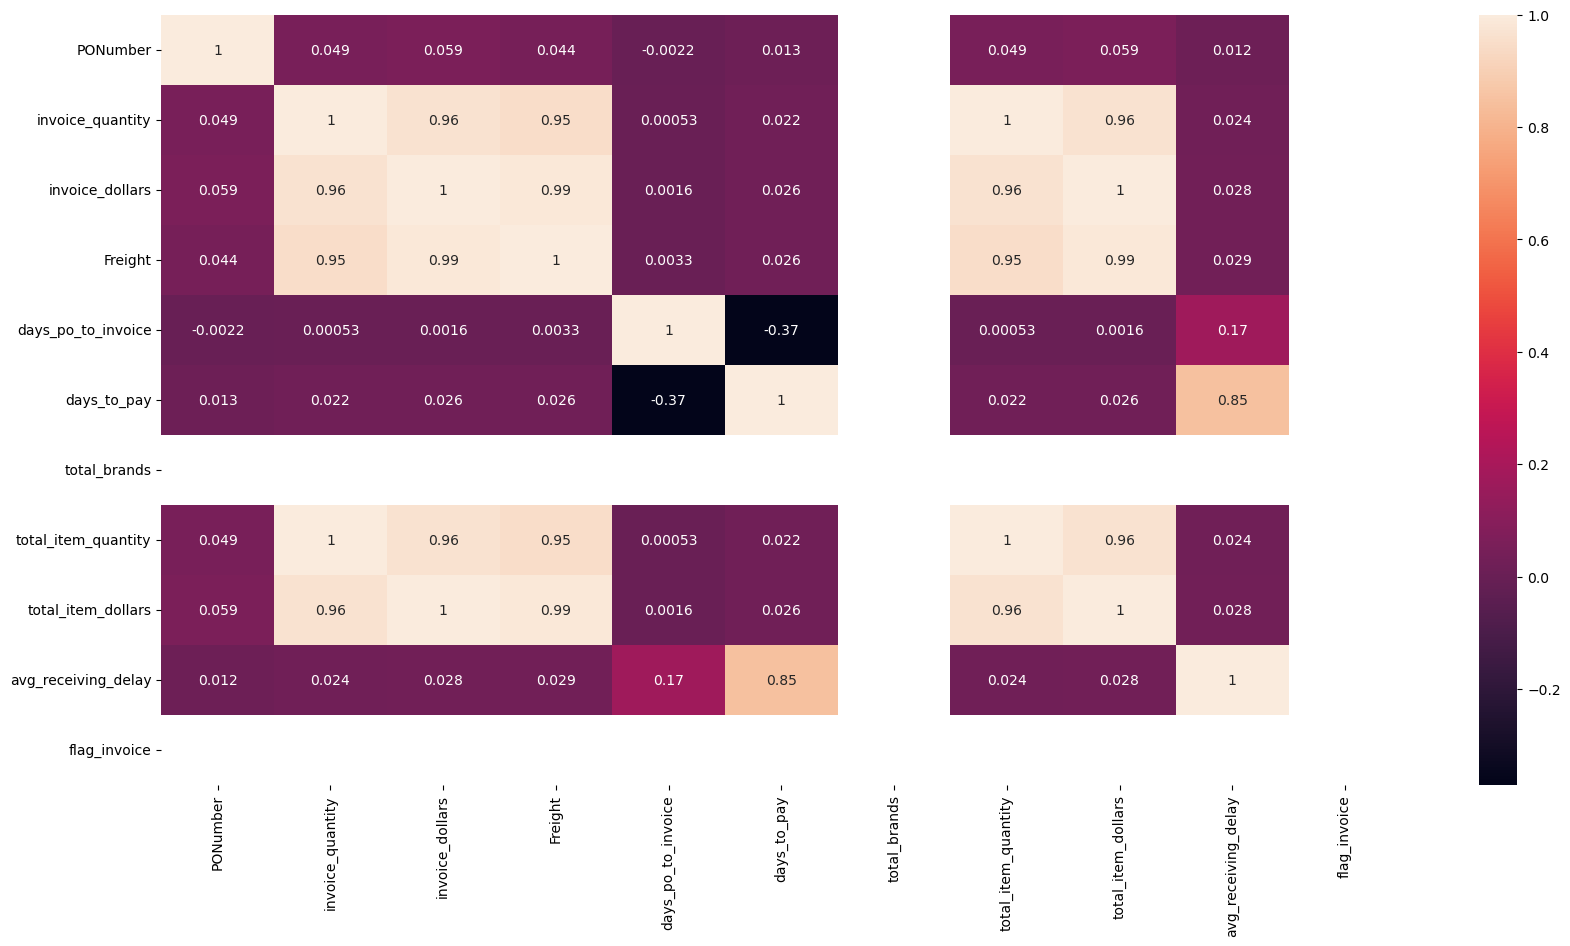

In [11]:
plt.figure(figsize=(20,10))
sns.heatmap(final_flagging_df.corr(numeric_only=True), annot=True)
plt.show()

In [12]:
flagged = final_flagging_df[final_flagging_df['flag_invoice'] == 1]
normal = final_flagging_df[final_flagging_df['flag_invoice'] == 0]

In [13]:
print("--- 1. Flag Counts ---")
print(final_flagging_df['flag_invoice'].value_counts())

print("\n--- 2. Actual Column Names ---")
print(final_flagging_df.columns.tolist())

print("\n--- 3. Sample Data Preview ---")
print(final_flagging_df.head(2))

--- 1. Flag Counts ---
flag_invoice
1    5543
Name: count, dtype: int64

--- 2. Actual Column Names ---
['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay', 'flag_invoice']

--- 3. Sample Data Preview ---
   PONumber  invoice_quantity  invoice_dollars  Freight  days_po_to_invoice  \
0      8124                 6           214.26     3.47                  14   
1      8137                15           140.55     8.57                  16   

   days_to_pay  total_brands  total_item_quantity  total_item_dollars  \
0           43             1                    6              214.26   
1           45             1                   15              140.55   

   avg_receiving_delay  flag_invoice  
0                 57.0             1  
1                 61.0             1  


In [14]:
import pandas as pd
from scipy.stats import ttest_ind

# 1. Dynamically calculate a realistic delay threshold based on your actual data median
median_delay = final_flagging_df["avg_receiving_delay"].median()
print(f"Adjusted threshold dynamically to: {median_delay} days to split your groups properly.\n")

# 2. Redefine the risk function using the customized threshold rule
def create_invoice_risk_label_fixed(row):
    if (abs(row["invoice_dollars"] - row["total_item_dollars"])) > 5:
        return 1
    if row["avg_receiving_delay"] > median_delay:  # Dynamic split rule
        return 1
    return 0

# 3. Apply the updated labels and check group counts
final_flagging_df["flag_invoice"] = final_flagging_df.apply(create_invoice_risk_label_fixed, axis=1)
print("--- New Balanced Flag Counts ---")
print(final_flagging_df['flag_invoice'].value_counts())
print("\n--------------------------------")

# 4. Separate into two tracking dataframes now that both groups exist
flagged = final_flagging_df[final_flagging_df['flag_invoice'] == 1]
normal = final_flagging_df[final_flagging_df['flag_invoice'] == 0]

significant_features = []
non_significant_features = []
results = []

metrics = [
    'invoice_quantity', 'invoice_dollars', 'Freight', 
    'days_po_to_invoice', 'days_to_pay', 'total_brands', 
    'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay'
]

# 5. Run the verification t-test loop
for metric in metrics:
    f_data = flagged[metric].dropna()
    n_data = normal[metric].dropna()
    
    if len(f_data) > 1 and len(n_data) > 1:
        flagged_mean = f_data.mean()
        normal_mean = n_data.mean()
        
        t_stat, p_value = ttest_ind(f_data, n_data, equal_var=False)
        
        if p_value < 0.05:
            significant_features.append(metric)
            results.append({
                "metric": metric,
                "flagged_mean": flagged_mean.round(2),
                "normal_mean": normal_mean.round(2),
                "p_value": p_value.round(3)
            })
        else:
            non_significant_features.append(metric)

# 6. Display the final completed dataframe directly
pd.DataFrame(results)

Adjusted threshold dynamically to: 52.0 days to split your groups properly.

--- New Balanced Flag Counts ---
flag_invoice
0    3014
1    2529
Name: count, dtype: int64

--------------------------------


C:\Users\chip\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,metric,flagged_mean,normal_mean,p_value
0,days_po_to_invoice,16.77,16.13,0.0
1,days_to_pay,40.24,31.46,0.0
2,avg_receiving_delay,57.01,47.60,0.0


In [15]:
X = final_flagging_df[[
    'invoice_quantity', 
    'invoice_dollars', 
    'Freight', 
    'total_brands', 
    'total_item_quantity', 
    'days_po_to_invoice', 
    'total_item_dollars'
]]

y = final_flagging_df['flag_invoice']

In [16]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,1.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,0.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,1.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,1.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,1.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,1.0,141660.0,23.0,1660436.0


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Perform the train-test split first so X_train and X_test exist
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize the scaler and scale the feature sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Initialize and train Logistic Regression
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

# 4. Initialize and train Decision Tree Classifier
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

# 5. Initialize and train Random Forest Classifier
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Define the correct classification evaluation function
def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    
    print(f"{model_name} Performance:")
    print(f"Accuracy : {accuracy:.2f}")
    print("Classification Report :")
    print(classification_report(y_test, preds))

# 2. Call the function for all three models exactly like the video screen
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')

Logistic Regression Performance:
Accuracy : 0.53
Classification Report :
              precision    recall  f1-score   support

           0       0.55      0.75      0.64       609
           1       0.47      0.26      0.34       500

    accuracy                           0.53      1109
   macro avg       0.51      0.51      0.49      1109
weighted avg       0.51      0.53      0.50      1109

Decision Tree Classifier Performance:
Accuracy : 0.54
Classification Report :
              precision    recall  f1-score   support

           0       0.58      0.56      0.57       609
           1       0.49      0.51      0.50       500

    accuracy                           0.54      1109
   macro avg       0.53      0.53      0.53      1109
weighted avg       0.54      0.54      0.54      1109

Random Forest Classifier Performance:
Accuracy : 0.51
Classification Report :
              precision    recall  f1-score   support

           0       0.55      0.57      0.56       609
        

In [19]:
import pandas as pd

# Create a DataFrame to rank which features matter most to the Random Forest model
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

# Display the ranked table output
feature_importance

,feature,importance
2,Freight,0.197298
1,invoice_dollars,0.188961
6,total_item_dollars,0.186247
4,total_item_quantity,0.166403
0,invoice_quantity,0.163614
5,days_po_to_invoice,0.097477
3,total_brands,0.000000


In [20]:
X = final_flagging_df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity', 'total_item_dollars']]
y = final_flagging_df['flag_invoice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model13 = RandomForestClassifier(random_state=42)
model13.fit(X_train_scaled, y_train)

evaluate_model(model13, X_test_scaled, y_test, 'Random Forest Classifier')

Random Forest Classifier Performance:
Accuracy : 0.52
Classification Report :
              precision    recall  f1-score   support

           0       0.56      0.59      0.58       609
           1       0.47      0.43      0.45       500

    accuracy                           0.52      1109
   macro avg       0.51      0.51      0.51      1109
weighted avg       0.52      0.52      0.52      1109



In [ ]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators":[100,200,300] ,
    "max_depth": [None, 4, 5, 6],
    "min_samples_split":[2,3,5],
    "min_samples_leaf":[1,2,5],
    "criterion": ['gini', 'entropy']
}

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# 1. Retrain model3 on your exact current scaled data to clear the error
model3 = RandomForestClassifier(random_state=42, n_jobs=-1)
model3.fit(X_train_scaled, y_train)

# 2. Run the exact confusion matrix matching the video layout
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[361, 283],
       [248, 217]])